In [1]:
print('test')

test


In [2]:

import pandas as pd
# 데이터 생성 (50개 샘플)
data = {
    '연소득(백만)': [45, 30, 80, 55, 120, 25, 60, 95, 35, 70, 42, 58, 110, 28, 75, 85, 48, 32, 130, 52, 65, 40, 90, 38, 72, 45, 55, 105, 30, 68, 82, 47, 53, 115, 27, 78, 88, 50, 34, 140, 55, 62, 41, 92, 39, 74, 46, 56, 100, 29],
    '신용점수': [700, 620, 780, 650, 820, 580, 710, 750, 600, 720, 680, 690, 800, 590, 740, 760, 670, 610, 840, 660, 700, 640, 770, 620, 730, 685, 695, 790, 595, 715, 765, 675, 665, 810, 585, 745, 775, 655, 615, 850, 670, 705, 630, 785, 625, 735, 680, 700, 795, 600],
    '부채비율(%)': [20, 45, 10, 30, 5, 55, 15, 12, 40, 18, 25, 22, 8, 50, 14, 11, 28, 42, 4, 32, 17, 35, 9, 38, 13, 21, 24, 7, 48, 16, 12, 26, 31, 6, 52, 15, 10, 29, 43, 3, 23, 18, 36, 11, 39, 14, 25, 20, 9, 47],
    '대출승인': [1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0],
    '승인금액(백만)': [20, 0, 50, 25, 80, 0, 30, 60, 0, 45, 22, 28, 70, 0, 40, 55, 0, 0, 90, 25, 35, 0, 65, 0, 45, 25, 30, 75, 0, 40, 55, 24, 0, 85, 0, 50, 60, 28, 0, 100, 30, 35, 0, 65, 0, 48, 26, 32, 70, 0]
}
df = pd.DataFrame(data)

In [4]:
df.head()

,연소득(백만),신용점수,부채비율(%),대출승인,승인금액(백만)
0,45,700,20,1,20
1,30,620,45,0,0
2,80,780,10,1,50
3,55,650,30,1,25
4,120,820,5,1,80


In [ ]:
# 1. 샘플이 몇개인가요?    50
# 2. 샘플 당 피처가 몇 개인가요?   6
# 3. 대출 승인 여부의 모델을 만든다면 분류? 회귀?   분류 
# 4. 대출 금액을 예상하는 모델을 만든다면 분류? 회귀? 회귀
# 5. 만약 회귀라면 어떤 모델을 선택해야 하나요? 다중, 다항
# 6. 만약 분류라면 어떤 모델을 선택해야 하나요? 로지스틱 회귀

# 위에서 분석하면,,,   EDA탐색 후 결측치나 이상치를 전략..
# 이것저것 다 해 보면서.. 최적의 답을 찾아 냅니다.

# 플러스
# 5번과 6번에서 언급한 모델은 데이터를 선형으로 봐서 공식을 만들겠다.
# 이상치의 영향이 클 수 있다..
# 오늘은 피처의 데이터를 선형으로 공식을 만드는 것이 아닌
# 피처를 보고 if문으로 트리를 만드는 비선형데이터로 보고 모델을 만든다.
# 피처를 보고 if문으로 트리를 만드는 모델을 결정트리라고 함.
# 결정트리는 비선형 데이터이고, 회귀와 분류  모두다 가능하다.

# 어제 당뇨병 문제는 로지스틱 회귀로 연구했죠. 
# 오늘은 모델을 결정트리를 추가해서 연구해 보면 그 차이가 있을 겁니다.

# 평가지표가 더 높으면 당뇨병은 로지스틱 회귀와 결정트리중에 어떤 것이
# 더 맞는 것인지 확인이 가능합니다
# 실제로도 다 해 봅니다.. 왜냐하면 인간이 데이터를 보고 분석하기 어렵기에
# 일단 모델에 따라 돌려보고 수정하며 최적을 답을 찾는다. 

In [ ]:
# 순서 데이터로드 >결측치> EDA탐색 > 데이터셋 > 모델선택..> 학습 > 평가
# 오늘 수업에서는 결측치랑  EDA 탐색 생략

In [ ]:
# 주제는 연소득과 신용점수와 부채비율 피처로 승인여부 판단 모델
# 승인여부이기 때문에 ... 분류 모델로 결정

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [9]:
# X, y선택하고
# 데이터 셋을 나눈다..
X =df[['연소득(백만)','신용점수','부채비율(%)']]
print(X.shape)
# print(X)
y=df['대출승인']
print(y.shape)

X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size= 0.2,
    random_state=42
)

(50, 3)
(50,)


In [ ]:
## 결정트리를 그려봅시다.
#                    혈당 : 126?
#                      /      \
#                     yes     no
#                   당뇨임    BMI > 30 ?
#                              /   \
#                            yes    no
#                            당뇨임  정상
#
# 용어
# Root Node    시작점,  Depth  3, left Node 최종결과
# 주의 : 각 노드에는 여러개의 샘플이 같이 있다..

In [ ]:
# 모델선택
# 비선형모델인 결정트리 모델을 선택
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(  #파라미터..
     #트리의 최대 깊이.. 중요한 파마리터
     #피처와 샘플데이터 에 비해서 너무 깊으면 과적합
     # 3개부터 10까지 조절하면서 .. 테스트
     max_depth= 3,
     #리프노드가 가져야 하는 최소 샘플 수  *중요한 파라미터
     #샘플 데이터가 많으면 5부터 차례대로 합니다.
     min_samples_leaf=5,  #5개의 샘플로 분류, 회귀 결과값
     
     #불순도 계산 방식  - 노드에 샘플 [승인4, 비승인8]
     criterion="gini"    
)

In [11]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

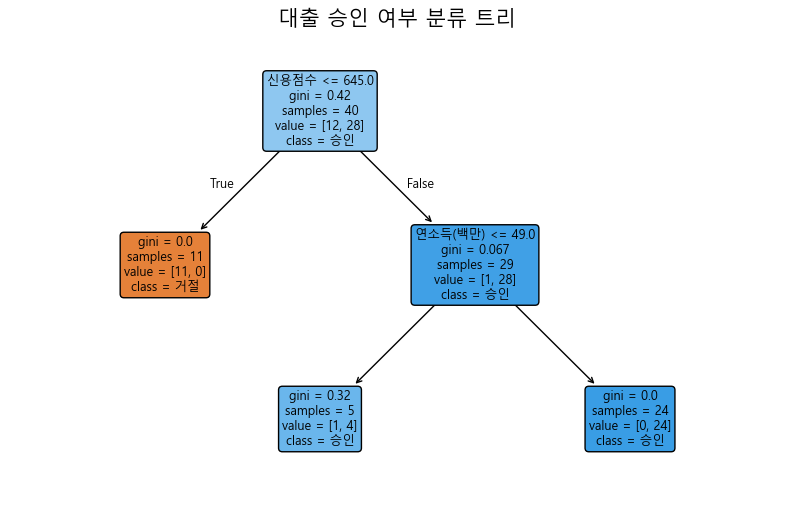

In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 1. 분류 모델 시각화
plt.figure(figsize=(10, 6))  # 크기를 15,10에서 10,6으로 줄임
plot_tree(model, 
          feature_names=X.columns, 
          class_names=['거절', '승인'], 
          filled=True, 
          rounded=True, 
          fontsize=9)  # 글자 크기를 조절하여 가독성 향상
plt.title("대출 승인 여부 분류 트리", fontsize=15)
plt.show()

In [ ]:
## 위쪽 트리가 한쪽으로 치우쳤다고 결론을 내려봤다. 
# 모델선택
# 비선형모델인 결정트리 모델을 선택
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(  #파라미터..
     #트리의 최대 깊이.. 중요한 파마리터
     #피처와 샘플데이터 에 비해서 너무 깊으면 과적합
     # 3개부터 10까지 조절하면서 .. 테스트
     max_depth= 3,
     #리프노드가 가져야 하는 최소 샘플 수  *중요한 파라미터
     #샘플 데이터가 많으면 5부터 차례대로 합니다.
     min_samples_leaf=5,  #5개의 샘플로 분류, 회귀 결과값
     #불순도 계산 방식  - 노드에 샘플 [승인4, 비승인8]
     criterion="gini",
     class_weight="balanced"  # 학습데이터가 정규분포라면
                          #이런 설정이 좋습니다  
)

In [14]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

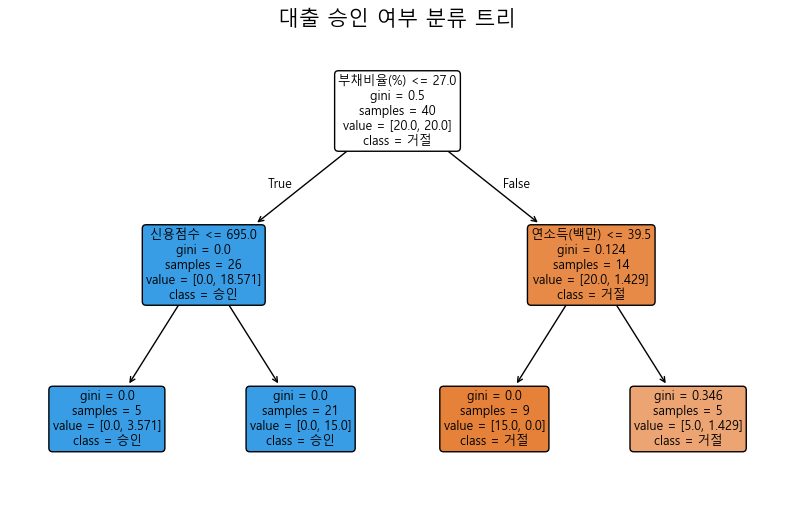

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 1. 분류 모델 시각화
plt.figure(figsize=(10, 6))  # 크기를 15,10에서 10,6으로 줄임
plot_tree(model, 
          feature_names=X.columns, 
          class_names=['거절', '승인'], 
          filled=True, 
          rounded=True, 
          fontsize=9)  # 글자 크기를 조절하여 가독성 향상
plt.title("대출 승인 여부 분류 트리", fontsize=15)
plt.show()

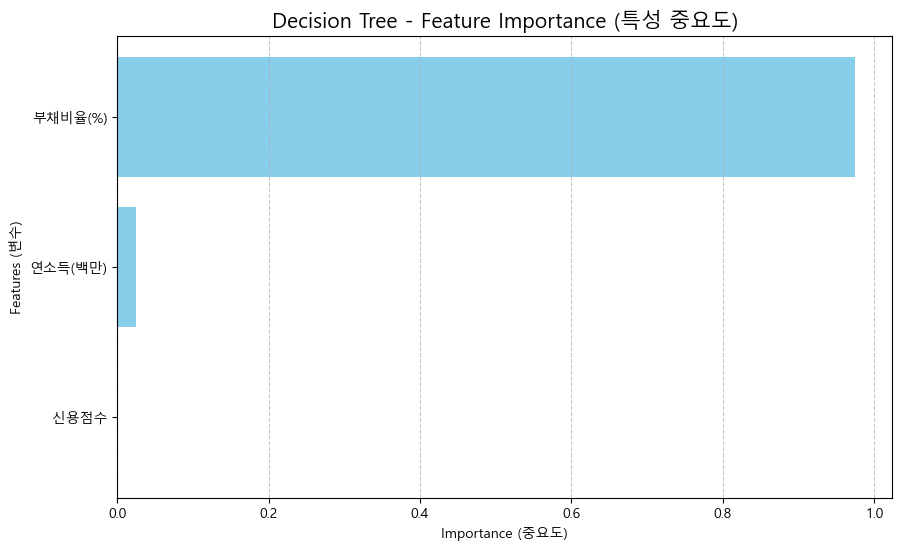

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 중요도 데이터 추출
# model는 이미 학습된 DecisionTreeClassifier 또는 DecisionTreeRegressor 객체여야 합니다.
importances = model.feature_importances_
feature_names = X.columns

# 2. 중요도 순으로 정렬 (보기 좋게 시각화하기 위함)
indices = np.argsort(importances)

# 3. 시각화
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.title("Decision Tree - Feature Importance (특성 중요도)", fontsize=15)
plt.xlabel("Importance (중요도)")
plt.ylabel("Features (변수)")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
# 중요도를 보고서 개발자가 도메인에서 판단하는 중요 피처가
# 모델이 얼마나 인지 했는 지 판다해서
# 샘플의 결과값을 기준으로 발란스를 맟주도록 추가하던가
# 전처리, 이상치 처리.하든가
# 샘플의 데이터를 더 추가해서 정상분포를 만들던가..

# 가장 잘 먹히는 전략은 전처리와 이상치도 중요하지만
# 샘플의 정확도다.
# 샘플의 품질이란 좋은 피처, 예측값 피처의 균형
# 승인과 거절피처의 비율이 7:3이라면 과적합의 원인이될 수 있다.
# 특히 이런 것은 분류모델에서는 매우 중요하다.
# 분류 모델은 대게 예측하려는 피처를 1:1로 많이 합니다.


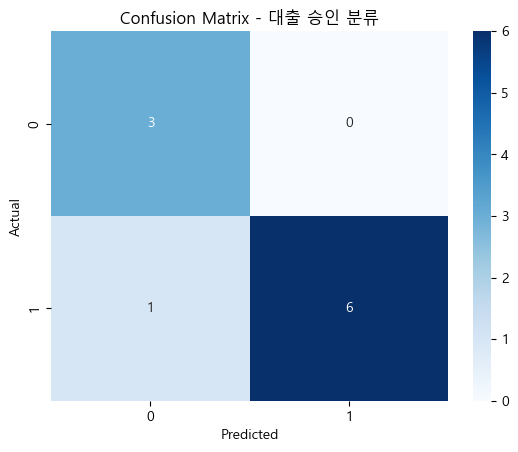

Accuracy: 0.9
Precision: 1.0
Recall: 0.8571428571428571
F1-score: 0.9230769230769231


In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

# Confusion Matrix 시각화
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - 대출 승인 분류')
plt.show()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

In [ ]:

# 과연 현실 데이터를 생각 할 때 트리의 모양은 발란스를 맞춰야 할까요?
# 발란스 맞추는게 고민을 해야 하는데..
# 금융 사기 탐지 : 사기1%   정상 99%
# 질병 예측   : 환자    정상  / 정상이 더 높을 듯
# 결정트리가 발란스 맞춰야 하는가? 질문은  피처의 특징을 고려하면 될 거 같습니다.
# 현실 데이터는 발란스 맞지 않는 경우가 많다.
# 모델 파라미터를 만들 때 발란스 옵션을 사용하지 않는게 성능이 좋을 수 있다.

# 결국 모델의 좋은 성능은 도메인 지식이다..는 좀 과한 결론을 내려 봅니다.


In [ ]:
## 